# Tutorial 3 — The Jacobian Lens and a Miniature J-Space

**Companion notebook, Part 3.** Released to attendees after the talk.

This notebook is a toy-scale walkthrough of Anthropic's **J-space / global workspace**
work (*A global workspace in language models*, transformer-circuits.pub, 2026): a small,
causally privileged set of activation patterns through which a language model carries
"silent" concepts that shape its future outputs. The discovery tool is the
**Jacobian lens (J-lens)**: for every vocabulary word, the internal activation pattern
that makes the model more likely to produce that word *later*.

The real paper's core objects, which we rebuild here at 1/100,000th scale:

- the context-averaged Jacobian `J_l = E[ d h_final,t' / d h_l,t ]` and the lens readout
  `softmax(W_U · norm(J_l · h))`, whose rows `W_U J_l` are the **J-lens vectors**;
- lens **reading**: ranking vocabulary by lens score to list a position's silent contents;
- **coordinate swap**: exchanging two concepts' lens coordinates via a pseudoinverse
  patch (`c = V^+ h; h += V(swap(c) − c)`) — the "France→China" intervention;
- **J-space ablation**: projecting out the top-k active lens vectors per position
  (excluding the clean pass's own output tokens) to test which *tasks* need the workspace.

**Important framing.** As in Tutorials 1–2, the domain is fake: a tiny transformer
trained on a synthetic entity–attribute language, so every mechanism is verifiable by
construction. The numbers and figures are real outputs of this notebook; claims about
real LLMs belong to the paper. Runs on GPU when available.

**References.** Paper: `transformer-circuits.pub/2026/workspace/index.html` (saved
alongside this notebook); announcement: `anthropic.com/research/global-workspace`;
code: `github.com/anthropics/jacobian-lens`; demo: `neuronpedia.org/jlens`.

In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

device: cuda (NVIDIA GeForce RTX 5070)


## 1. A synthetic world with things to silently think about

Vocabulary: 8 **entities** (stand-ins for "France", "China", …), each with three fixed
**attributes** — a capital, a language, a currency (24 distinct answer tokens). Plus
4 **filler** tokens that follow their own little grammar (next filler = current+1 mod 4,
90% of the time), and 4 **query** tokens.

Every training sequence is `BOS  E_i  f f f f f  Q  A`: an entity is mentioned once,
five filler tokens intervene, then a query asks for the capital / language / currency /
identity of the entity, and the answer follows. A fifth of sequences are pure filler
with no query. So the model must learn two very different skills:

- **a practiced local skill** — predicting the next filler token (needs no memory of
  the entity), and
- **workspace-style recall** — carrying "the entity is E_3" silently across the filler
  span and converting it into whichever attribute the query demands.

The `Q_id` query (answer: the entity token itself) matters technically: it makes entity
tokens appear as *outputs*, so the J-lens has a well-defined pattern for them.

In [2]:
# --- vocabulary layout ---
BOS = 0
ENT = list(range(1, 9))                       # E0..E7
FILL = list(range(9, 13))                     # f0..f3
Q_CAP, Q_LANG, Q_CUR, Q_ID = 13, 14, 15, 16
QUERIES = [Q_CAP, Q_LANG, Q_CUR, Q_ID]
CAP = list(range(17, 25))                     # cap0..cap7
LANG = list(range(25, 33))                    # lang0..lang7
CUR = list(range(33, 41))                     # cur0..cur7
V_SIZE = 41
T_LEN = 9                                     # BOS E f f f f f Q A
Q_POS = 7                                     # fixed query position

NAMES = (["BOS"] + [f"E{i}" for i in range(8)] + [f"f{i}" for i in range(4)]
         + ["Qcap", "Qlang", "Qcur", "Qid"]
         + [f"cap{i}" for i in range(8)] + [f"lang{i}" for i in range(8)]
         + [f"cur{i}" for i in range(8)])


def answer_token(entity_idx: int, query: int) -> int:
    return {Q_CAP: CAP[entity_idx], Q_LANG: LANG[entity_idx],
            Q_CUR: CUR[entity_idx], Q_ID: ENT[entity_idx]}[query]


def filler_walk(n: int, start: torch.Tensor) -> torch.Tensor:
    """Filler grammar: next = current+1 mod 4 with p=0.9, else uniform random."""
    out = [start]
    for _ in range(n - 1):
        nxt = (out[-1] + 1) % 4
        rnd = torch.randint(0, 4, nxt.shape, device=device)
        use_rnd = torch.rand(nxt.shape, device=device) < 0.1
        out.append(torch.where(use_rnd, rnd, nxt))
    return torch.stack(out, dim=1)


def make_batch(B: int, p_query: float = 0.8):
    ent = torch.randint(0, 8, (B,), device=device)
    q = torch.tensor(np.random.choice(QUERIES, size=B), device=device)
    has_q = torch.rand(B, device=device) < p_query
    fill = filler_walk(6, torch.randint(0, 4, (B,), device=device)) + FILL[0]
    seq = torch.zeros(B, T_LEN, dtype=torch.long, device=device)
    seq[:, 0] = BOS
    seq[:, 1] = ent + ENT[0]
    seq[:, 2:7] = fill[:, :5]
    ans = torch.tensor([answer_token(int(e), int(qq)) for e, qq in zip(ent, q)],
                       device=device)
    seq[:, 7] = torch.where(has_q, q, fill[:, 5])
    # last token: answer if queried, else one more filler step
    last_fill = (fill[:, 5] - FILL[0] + 1) % 4 + FILL[0]
    seq[:, 8] = torch.where(has_q, ans, last_fill)
    return seq, ent, q, has_q


seq, ent, q, has_q = make_batch(4)
for s in seq:
    print(" ".join(NAMES[t] for t in s.tolist()))

BOS E5 f1 f2 f3 f0 f1 f2 f3
BOS E1 f3 f0 f3 f0 f1 Qid E1
BOS E7 f0 f2 f3 f0 f1 Qlang lang7
BOS E4 f3 f0 f1 f2 f3 Qcap cap4


## 2. A tiny transformer, trained to competence

4 pre-norm blocks, d_model 128, 4 heads — small enough that the whole J-lens machinery
runs in seconds, deep enough to have "early / middle / late" processing. We tap the
residual stream at 5 points: after the embedding and after each block.

In [3]:
class Block(nn.Module):
    def __init__(self, d: int, heads: int) -> None:
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x = x + a
        x = x + self.mlp(self.ln2(x))
        return x


class TinyLM(nn.Module):
    def __init__(self, d: int = 128, heads: int = 4, n_blocks: int = 4) -> None:
        super().__init__()
        self.tok = nn.Embedding(V_SIZE, d)
        self.pos = nn.Embedding(T_LEN, d)
        self.blocks = nn.ModuleList([Block(d, heads) for _ in range(n_blocks)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, V_SIZE, bias=False)
        mask = torch.triu(torch.ones(T_LEN, T_LEN), diagonal=1).bool()
        self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor, patch=None):
        """patch: optional dict {tap_index: fn(h) -> h} applied to the residual stream.
        Returns (logits, taps) where taps[i] is the residual after tap i (0 = embeddings)."""
        h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
        taps = []
        if patch and 0 in patch:
            h = patch[0](h)
        taps.append(h)
        for i, blk in enumerate(self.blocks):
            h = blk(h, self.mask[: x.shape[1], : x.shape[1]])
            if patch and (i + 1) in patch:
                h = patch[i + 1](h)
            taps.append(h)
        return self.head(self.ln_f(h)), taps


model = TinyLM().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
for step in range(4000):
    seq, ent, q, has_q = make_batch(512)
    logits, _ = model(seq)
    loss = F.cross_entropy(logits[:, :-1].reshape(-1, V_SIZE), seq[:, 1:].reshape(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
print(f"final train loss: {loss.item():.3f}")


@torch.no_grad()
def accuracies(n: int = 4000):
    seq, ent, q, has_q = make_batch(n)
    logits, _ = model(seq)
    pred = logits.argmax(-1)
    recall = (pred[has_q, Q_POS] == seq[has_q, Q_POS + 1]).float().mean().item()
    fill_pos = pred[:, 2:6] == seq[:, 3:7]        # filler→filler predictions
    return recall, fill_pos.float().mean().item()


recall_acc, filler_acc = accuracies()
print(f"recall accuracy (answering queries): {recall_acc:.3f}")
print(f"filler-grammar accuracy:             {filler_acc:.3f}  (ceiling ≈ 0.925)")

final train loss: 0.810
recall accuracy (answering queries): 1.000
filler-grammar accuracy:             0.924  (ceiling ≈ 0.925)


## 3. The Jacobian lens

The paper's lens is `J_l = E[ d h_final,t' / d h_l,t ]` — the expected first-order
effect of the residual stream at layer *l*, position *t*, on the final-layer stream at
future positions — followed by the unembedding: the J-lens vector for word *w* is row
*w* of `W_U J_l`. Applying the lens to an activation ranks the vocabulary by how
strongly that activation *promotes each word's future output*.

Our toy simplification: the interesting future output is the answer position, so we
take `t' = Q_POS` and compute, for every word *w* and tap *l*, the batch-averaged
gradient of the answer-position logit of *w* with respect to the residual at *l* —
folding the final LayerNorm and unembedding into one linearized map. One backward pass
per vocabulary word (41 total) yields lens vectors for **every layer and position at
once**; averaging over prompts gives the context-averaged lens, one `[V, d]` matrix per
(tap, source position).

The **logit lens** — the classic baseline — is the special case `J = I`: read the
residual with the unembedding directly. The paper's point is that this only works in
late layers; the Jacobian correction recovers readable content earlier. We test exactly
that claim below.

In [4]:
def compute_lens(n_prompts: int = 256):
    """Returns lens[tap][t] as a [V, d] tensor of context-averaged J-lens vectors."""
    seq, ent, q, has_q = make_batch(n_prompts, p_query=1.0)
    logits, taps = model(seq)
    n_taps = len(taps)
    lens = torch.zeros(n_taps, T_LEN, V_SIZE, taps[0].shape[-1], device=device)
    for w in range(V_SIZE):
        grads = torch.autograd.grad(
            logits[:, Q_POS, w].sum(), taps, retain_graph=(w < V_SIZE - 1)
        )
        for l, g in enumerate(grads):
            lens[l, :, w] = g.mean(0)  # average over prompts; [T, d]
    return lens


LENS = compute_lens()
N_TAPS = LENS.shape[0]
print(f"lens computed: {N_TAPS} taps × {T_LEN} positions × {V_SIZE} words × d=128")


def lens_scores(taps, tap: int, t: int) -> torch.Tensor:
    """J-lens readout: [B, V] scores at (tap, position)."""
    return taps[tap][:, t] @ LENS[tap, t].T


def logit_lens_scores(taps, tap: int, t: int) -> torch.Tensor:
    return model.head(model.ln_f(taps[tap][:, t]))

lens computed: 5 taps × 9 positions × 41 words × d=128


## 4. J-lens vs logit lens: where does the answer become readable?

For a fresh batch of queried sequences, we track the *rank of the eventual answer
token* under both lenses, at every tap, reading the query position. If the Jacobian
correction matters, the J-lens should surface the answer several layers before the
logit lens does.

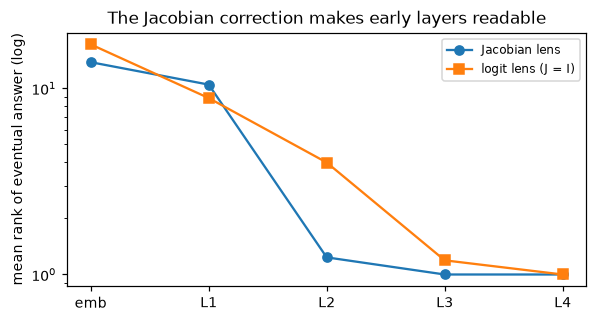

mean answer rank by tap —  J-lens: ['13.8', '10.5', '1.2', '1.0', '1.0']  logit lens: ['17.2', '8.9', '4.0', '1.2', '1.0']


In [5]:
with torch.no_grad():
    seq, ent, q, has_q = make_batch(2000, p_query=1.0)
    _, taps = model(seq)
    ans = seq[:, Q_POS + 1]

    def mean_rank(score_fn):
        ranks = []
        for l in range(N_TAPS):
            s = score_fn(taps, l, Q_POS)
            r = (s > s.gather(1, ans[:, None])).sum(1).float().mean().item()
            ranks.append(r + 1)
        return ranks

    jr, lr = mean_rank(lens_scores), mean_rank(logit_lens_scores)

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(range(N_TAPS), jr, marker="o", label="Jacobian lens")
ax.plot(range(N_TAPS), lr, marker="s", label="logit lens (J = I)")
ax.set_yscale("log")
ax.set_xticks(range(N_TAPS), ["emb", "L1", "L2", "L3", "L4"])
ax.set_ylabel("mean rank of eventual answer (log)")
ax.set_title("The Jacobian correction makes early layers readable")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("mean answer rank by tap —  J-lens:", [f"{r:.1f}" for r in jr],
      " logit lens:", [f"{r:.1f}" for r in lr])

## 5. Reading the workspace: silent contents, position by position

Two readings. First, the evolution at the **query position**: in early taps the lens
reads only generic, undifferentiated concept directions; by the middle taps the
*specific* entity rises to the top — followed by its attributes, none of which appear
anywhere in the text — and the late taps sharpen to the specific answer (the "motor"
stage). Second, a **map of where the concept lives**: the lens rank of the entity token
at every (tap, position) — the toy analog of the paper's workspace heatmaps.

sequence:  BOS E4 f0 f1 f2 f3 f0 Qid E4

J-lens top-5 readout at the query position, per tap:
  tap 0 (emb): E2, E3, E0, E5, E4
  tap 1 (L1): E2, E0, E5, E3, E4
  tap 2 (L2): E4, E2, E0, E5, E3
  tap 3 (L3): E4, cap4, cur4, lang1, E2
  tap 4 (L4): E4, E6, E3, E0, E5


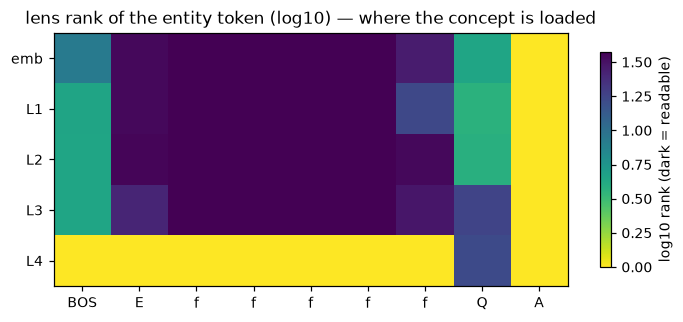

In [6]:
with torch.no_grad():
    demo_seq, demo_ent, demo_q, _ = make_batch(1, p_query=1.0)
    _, demo_taps = model(demo_seq)
print("sequence: ", " ".join(NAMES[t] for t in demo_seq[0].tolist()))
print(f"\nJ-lens top-5 readout at the query position, per tap:")
for l in range(N_TAPS):
    s = lens_scores(demo_taps, l, Q_POS)[0]
    top = s.topk(5).indices.tolist()
    print(f"  tap {l} ({['emb','L1','L2','L3','L4'][l]}): "
          + ", ".join(NAMES[t] for t in top))

with torch.no_grad():
    seq, ent, q, has_q = make_batch(2000, p_query=1.0)
    _, taps = model(seq)
    ent_tok = seq[:, 1]
    rank_map = np.zeros((N_TAPS, T_LEN))
    for l in range(N_TAPS):
        for t in range(T_LEN):
            s = taps[l][:, t] @ LENS[l, t].T
            r = (s > s.gather(1, ent_tok[:, None])).sum(1).float().mean().item()
            rank_map[l, t] = r + 1

fig, ax = plt.subplots(figsize=(6.5, 3))
im = ax.imshow(np.log10(rank_map), aspect="auto", cmap="viridis_r")
ax.set_xticks(range(T_LEN), ["BOS", "E", "f", "f", "f", "f", "f", "Q", "A"])
ax.set_yticks(range(N_TAPS), ["emb", "L1", "L2", "L3", "L4"])
ax.set_title("lens rank of the entity token (log10) — where the concept is loaded")
fig.colorbar(im, ax=ax, shrink=0.85, label="log10 rank (dark = readable)")
fig.tight_layout()
plt.show()

## 6. The geometry of the lens dictionary

Two structural checks that echo the paper's analysis (and Tutorial 1's geometry):

- **Effective dimensionality** of the lens matrix `W_U J_l` per tap — how many
  directions of the residual stream actually route to future outputs. In the paper this
  is low early, rises at workspace onset, rises again in the motor stage.
- **Concept clustering**: cosine similarity between the lens vectors of every entity
  and its three attributes, ordered by entity. Block structure means "E3", "cap3",
  "lang3", "cur3" share workspace geometry — the model's concept of entity 3 is a small
  subspace, not four unrelated directions. (This is where a manifold analysis of
  concept *families* would begin at scale.)

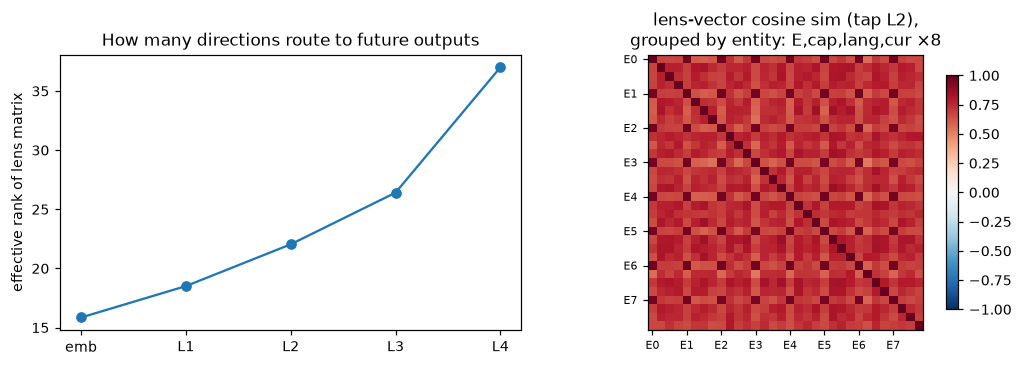

effective rank per tap: ['15.9', '18.5', '22.0', '26.4', '37.0']


In [7]:
def effective_rank(M: torch.Tensor) -> float:
    s = torch.linalg.svdvals(M)
    p = s / s.sum()
    return float(torch.exp(-(p * torch.log(p + 1e-12)).sum()))


eff = [effective_rank(LENS[l, Q_POS]) for l in range(N_TAPS)]

concept_order = [t for i in range(8) for t in (ENT[i], CAP[i], LANG[i], CUR[i])]
mid = 2
Vmat = LENS[mid, Q_POS][concept_order]
Vn = Vmat / Vmat.norm(dim=1, keepdim=True)
sim = (Vn @ Vn.T).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
axs[0].plot(range(N_TAPS), eff, marker="o")
axs[0].set_xticks(range(N_TAPS), ["emb", "L1", "L2", "L3", "L4"])
axs[0].set_ylabel("effective rank of lens matrix")
axs[0].set_title("How many directions route to future outputs")
im = axs[1].imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
axs[1].set_title("lens-vector cosine sim (tap L2),\ngrouped by entity: E,cap,lang,cur ×8")
axs[1].set_xticks(range(0, 32, 4), [f"E{i}" for i in range(8)], fontsize=7)
axs[1].set_yticks(range(0, 32, 4), [f"E{i}" for i in range(8)], fontsize=7)
fig.colorbar(im, ax=axs[1], shrink=0.85)
fig.tight_layout()
plt.show()
print("effective rank per tap:", [f"{e:.1f}" for e in eff])

## 7. The coordinate swap: "France → China"

The paper's flagship intervention. Take two concepts' lens vectors, `V = [v_a, v_b]`;
read the activation's coordinates along them via the pseudoinverse, `c = V⁺h`; then
write back with the coordinates exchanged: `h ← h + V(swap(c) − c)`. Everything
orthogonal to the concept directions is untouched. We patch one middle tap, at every
position, using each position's own lens vectors.

The paper's flexibility claim — one shared representation feeds *all* queries — becomes
testable here: a single swap of entity a → entity b should flip the answer for the
capital, language, currency, and identity queries alike.

One honest wrinkle worth teaching: swapping along the **single** entity-token direction
only flips the identity query. In this toy, the direction that promotes the *word* "E4"
is not the whole internal concept of entity 4 — the attribute-answer machinery reads
other components. Swapping the **concept block** — the entity's lens vector *and* its
three attributes' lens vectors, exchanged pairwise — flips everything. (In Claude, a
single token's pattern sufficed; a 41-word toy world simply has less structure packed
into each direction. The failure mode, "your intervention vector under-covers the
concept", is one you will meet on real models too.)

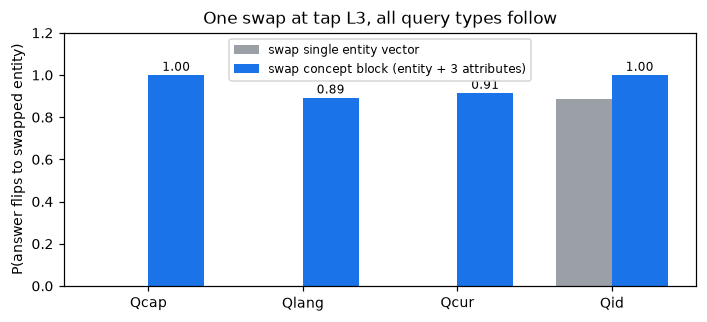

single-vector swap: {'Qcap': '0.00', 'Qlang': '0.00', 'Qcur': '0.00', 'Qid': '0.89'}
concept-block swap: {'Qcap': '1.00', 'Qlang': '0.89', 'Qcur': '0.91', 'Qid': '1.00'}


In [8]:
def swap_patch_fn(tap: int, a: int, b: int, block: bool, alpha: float = 1.0):
    """Pseudoinverse coordinate swap of entity a <-> b, per-position lens vectors."""
    if block:
        toks_a = [ENT[a], CAP[a], LANG[a], CUR[a]]
        toks_b = [ENT[b], CAP[b], LANG[b], CUR[b]]
    else:
        toks_a, toks_b = [ENT[a]], [ENT[b]]
    n = len(toks_a)

    def fn(h: torch.Tensor) -> torch.Tensor:
        out = h.clone()
        for t in range(h.shape[1]):
            Vcols = torch.stack([LENS[tap, t, tk] for tk in toks_a + toks_b], dim=1)
            c = h[:, t] @ torch.linalg.pinv(Vcols).T          # [B, 2n]
            swapped = torch.cat([c[:, n:], c[:, :n]], dim=1)  # exchange a- and b-blocks
            out[:, t] = h[:, t] + alpha * (swapped - c) @ Vcols.T
        return out

    return fn


SWAP_TAP = 3
results = {blk: {} for blk in (False, True)}
with torch.no_grad():
    for blk in (False, True):
        for query in QUERIES:
            n_ok, n_tot = 0, 0
            for a in range(8):
                b = (a + 3) % 8
                seq, ent, qv, _ = make_batch(400, p_query=1.0)
                pick = (ent == a) & (qv == query)
                if pick.sum() == 0:
                    continue
                logits, _ = model(
                    seq[pick], patch={SWAP_TAP: swap_patch_fn(SWAP_TAP, a, b, blk)}
                )
                pred = logits[:, Q_POS].argmax(-1)
                n_ok += (pred == answer_token(b, query)).sum().item()
                n_tot += len(seq[pick])
            results[blk][NAMES[query]] = n_ok / n_tot

fig, ax = plt.subplots(figsize=(6.5, 3))
names = [NAMES[qq] for qq in QUERIES]
xpos = np.arange(len(names))
ax.bar(xpos - 0.18, [results[False][n] for n in names], 0.36,
       label="swap single entity vector", color="#9aa0a6")
ax.bar(xpos + 0.18, [results[True][n] for n in names], 0.36,
       label="swap concept block (entity + 3 attributes)", color="#1a73e8")
for x, v in zip(xpos + 0.18, [results[True][n] for n in names]):
    ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(xpos, names)
ax.set_ylim(0, 1.2)
ax.set_ylabel("P(answer flips to swapped entity)")
ax.set_title(f"One swap at tap L{SWAP_TAP}, all query types follow")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("single-vector swap:", {k: f"{v:.2f}" for k, v in results[False].items()})
print("concept-block swap:", {k: f"{v:.2f}" for k, v in results[True].items()})

## 8. Ablating the J-space: which tasks actually need the workspace?

The paper's dissociation result: killing the J-space leaves fluent, practiced behavior
intact but destroys tasks that must *route information through* the workspace.

The paper's exact procedure — zero out the top-10 most-activated lens vectors per
position, excluding the clean pass's own output tokens — assumes thousands of residual
dimensions, of which ten are a sliver. At d=128 it is a sledgehammer: the top-activated
lens vectors overlap the stream's dominant shared components, and zero-projecting them
destroys *everything* (we verified — even k=2 flattens the filler skill). The
toy-appropriate rendition uses two lessons this tutorial series already taught:

- ablate the **fixed concept-lens subspace** (all 32 entity+attribute lens vectors,
  orthonormalized per position) rather than per-sample top-k picks, and
- **mean-ablate** (reset coordinates to their batch mean, Tutorial 1's lesson) rather
  than zero-project, so we remove the *information*, not a quarter of the norm.

Control: mean-ablate a random 32-dimensional subspace instead.

Prediction: recall collapses, the filler grammar survives, and the random control
separates cleanly.

clean                            recall=1.000  filler=0.928
concept-lens subspace ablated    recall=0.000  filler=0.927
random subspace (control)        recall=0.659  filler=0.924


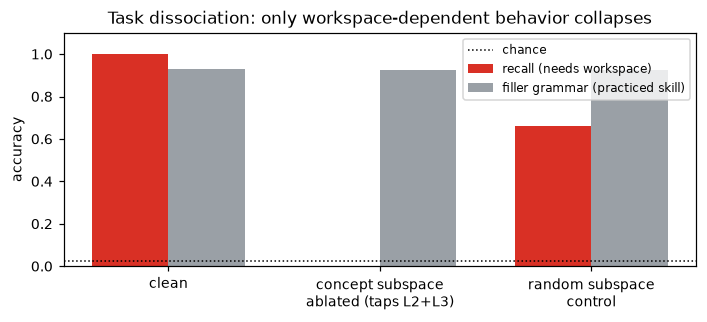

In [9]:
CONCEPT_TOKS = ENT + CAP + LANG + CUR


def subspace_ablate_fn(tap: int, random_subspace: bool = False):
    ids = torch.tensor(CONCEPT_TOKS, device=device)

    def fn(h: torch.Tensor) -> torch.Tensor:
        out = h.clone()
        for t in range(h.shape[1]):
            if random_subspace:
                g = torch.Generator().manual_seed(tap * 100 + t)
                basis = torch.randn(len(ids), h.shape[-1], generator=g).to(h.device)
            else:
                basis = LENS[tap, t][ids]
            Qmat, _ = torch.linalg.qr(basis.T)        # [d, 32] orthonormal
            coef = out[:, t] @ Qmat                   # [B, 32]
            coef = coef - coef.mean(0, keepdim=True)  # mean-ablation
            out[:, t] = out[:, t] - coef @ Qmat.T
        return out

    return fn


@torch.no_grad()
def eval_with_patch(patch) -> tuple[float, float]:
    seq, ent, qv, has_q = make_batch(2000)
    logits, _ = model(seq, patch=patch)
    pred = logits.argmax(-1)
    recall = (pred[has_q, Q_POS] == seq[has_q, Q_POS + 1]).float().mean().item()
    filler = (pred[:, 2:6] == seq[:, 3:7]).float().mean().item()
    return recall, filler


conds = {
    "clean": None,
    "concept-lens subspace ablated": {2: subspace_ablate_fn(2), 3: subspace_ablate_fn(3)},
    "random subspace (control)": {2: subspace_ablate_fn(2, True),
                                  3: subspace_ablate_fn(3, True)},
}
rec, fil = {}, {}
for name, patch in conds.items():
    rec[name], fil[name] = eval_with_patch(patch)
    print(f"{name:32s} recall={rec[name]:.3f}  filler={fil[name]:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3))
xpos = np.arange(len(conds))
ax.bar(xpos - 0.18, [rec[n] for n in conds], 0.36, label="recall (needs workspace)",
       color="#d93025")
ax.bar(xpos + 0.18, [fil[n] for n in conds], 0.36, label="filler grammar (practiced skill)",
       color="#9aa0a6")
ax.set_xticks(xpos, ["clean", "concept subspace\nablated (taps L2+L3)",
                     "random subspace\ncontrol"])
ax.axhline(1 / V_SIZE, color="k", ls=":", lw=1, label="chance")
ax.set_ylim(0, 1.1)
ax.set_ylabel("accuracy")
ax.set_title("Task dissociation: only workspace-dependent behavior collapses")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. What changes at scale, and what to take home

| This notebook | The real paper (Claude Sonnet/Opus 4.x) |
|---|---|
| 41-word vocab, one future position (`t' = Q_POS`) | full vocab; Jacobian averaged over all `t' ≥ t` and 1,000 pretraining-like prompts |
| 5 taps on a 4-block model | 25 sampled layers; workspace band ≈ L38–L92 of 100 |
| dense lens readout | sparse non-negative decomposition (gradient pursuit, k ≤ 25) defines the J-space proper |
| entity concepts by construction | emergent concepts: plans, assessments, "fake"/"manipulation" during misbehavior |
| swap flips 4 query types | one France→China swap redirects capitals, languages, continents, currencies |
| concept-subspace mean-ablation (32 of 128 dims) | top-10-activated lens vectors zeroed per position, clean outputs excluded |
| recall vs filler dissociation | GSM8K/multihop collapse under ablation; MMLU/classification survive |

Three transferable lessons: (1) *causal influence on future outputs* — not geometric
density — is what picked out this low-dimensional structure; the lens is a **Jacobian**,
i.e. the same derivative object we used for steering and adversarial masks in Tutorials
1–2, pointed at a new question. (2) The logit lens is the `J = I` special case; the
correction is what makes middle layers readable. (3) Every claim came with an
intervention (swap, ablation, control) — reading alone proves representation, not use.

**Caveats inherited from the paper:** single-token concepts only; first-order
(linearized) causal estimates; the workspace runs across *depth*, not time; and the toy
model here trivially *must* route recall through its residual stream — in a real LLM,
discovering that a workspace exists at all is the finding. **Toy-specific caveats we
hit live:** a single token's lens vector under-covers a concept in a small model (the
swap needed the 4-vector concept block), and top-k-activated zero-projection needs
thousands of dimensions of headroom (the ablation needed the fixed-subspace,
mean-ablation rendition).

**References.** *A global workspace in language models*, transformer-circuits.pub, 2026
(local copy: `jspace_paper_transformer_circuits.html`); announcement:
`anthropic.com/research/global-workspace`; open-source lens:
`github.com/anthropics/jacobian-lens`; interactive demo: `neuronpedia.org/jlens`.